In [1]:
import nextnanopy as nn
import os
import matplotlib.pyplot as plt
import numpy as np
import sys


In [2]:
path_nextnanoprojects_tools = r"C:\Users\sp6497_a\nextnanopy_projects"

In [3]:
print(sys.path)
sys.path.append(path_nextnanoprojects_tools)
print(sys.path)
from nextnano_tools.helper_functions import build_output
from nextnano_tools.simstructs import SimOut, BandStructure, Eigenstate

['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\Pythonwin']
['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\min

In [4]:
bias = r'bias_00000'
quantum_region = r'Quantum\quantum_region'
quantum_band = r'Gamma'
quantum_band_interactions = r'Gamma_Gamma'

C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1DSL_7p5nm_2p5nm_Gamma_Nwell_sweep(6)\bias_00000\OpticsQuantum\quantum_region


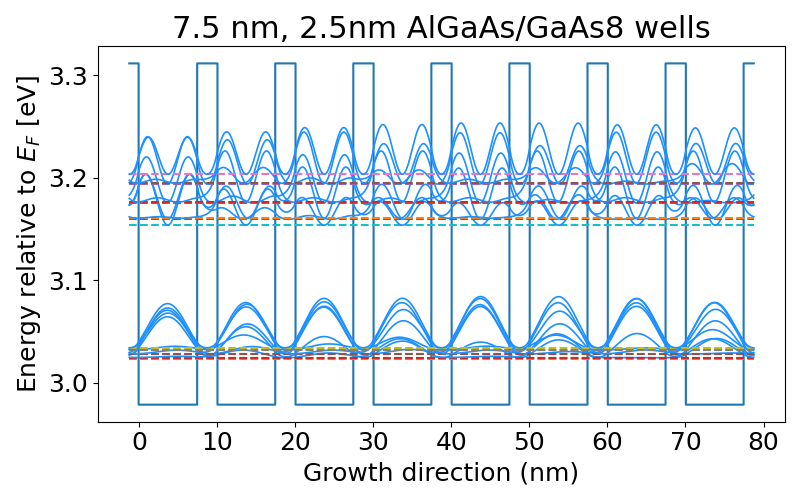


Intersubband transition energies — CB
-----------------------------------------------------
 i → j | ΔE (eV)
-----------------------------------------------------
  6 →  7 | -0.0002
  4 →  5 | -0.0002
  2 →  3 | -0.0003
 14 → 15 | -0.0007
 12 → 13 | -0.0009
 10 → 11 | -0.0010
  1 →  2 | -0.0013
  1 →  3 | -0.0016
  7 →  8 | -0.0018
  6 →  8 | -0.0020
  3 →  4 | -0.0034
  3 →  5 | -0.0036
  2 →  4 | -0.0037
  5 →  6 | -0.0039
  2 →  5 | -0.0039
  5 →  7 | -0.0041
  4 →  6 | -0.0041
  4 →  7 | -0.0043
  1 →  4 | -0.0050
  1 →  5 | -0.0052
  9 → 10 | -0.0058
  5 →  8 | -0.0059
  4 →  8 | -0.0061
  9 → 11 | -0.0068
  3 →  6 | -0.0075
  3 →  7 | -0.0077
  2 →  6 | -0.0078
  2 →  7 | -0.0080
 15 → 16 | -0.0088
  1 →  6 | -0.0091
  1 →  7 | -0.0093
 14 → 16 | -0.0095
  3 →  8 | -0.0095
  2 →  8 | -0.0098
  1 →  8 | -0.0111
 11 → 12 | -0.0149
 11 → 13 | -0.0157
 10 → 12 | -0.0158
 10 → 13 | -0.0167
 13 → 14 | -0.0177
 13 → 15 | -0.0184
 12 → 14 | -0.0186
 12 → 15 | -0.0193
  9 → 12 | -0.0216


In [5]:
%matplotlib widget
outs_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output"
parent_dir = os.path.join(outs_dir, r"1DSL_7p5nm_2p5nm_Gamma_Nwell_sweep(6)")
VB_cutoff = 2.0
simoutidk = build_output(parent_dir,quantum_region,quantum_band,quantum_band_interactions,bias,VB_cutoff,14,model='gamma')
simoutidk.bands['CB'].sort_subbands(decreasing=False)

simoutidk.bands['CB'].plot_band(title_diff='7.5 nm, 2.5nm AlGaAs/GaAs' +str(simoutidk.variables['NUMBER_OF_WELLS']) + ' wells',normalize_y=False,show_legend=False)
simoutidk.bands['CB'].calc_intersubband_transitions()
simoutidk.bands['CB'].display_intersubband_transitions(upward_only=True,sort_by_deltaE="descending")

# simoutidk.optical_absorption.get_spectrum('TM-z').plot(show_grid=True)

In [6]:
simoutidk.variables['NUMBER_OF_WELLS']

8

In [7]:
import glob

base_name = '1DSL_7p5nm_2p5nm_Gamma_Nwell_sweep'
sweep_dirs = sorted(glob.glob(os.path.join(outs_dir, base_name + '*')))

VB_cutoff = 2.0
sweep_results = []  # list of (N_wells, sorted CB energies)

for d in sweep_dirs:
    simout = build_output(d, quantum_region, quantum_band, quantum_band_interactions,
                          bias, VB_cutoff, well_w=0, model='gamma')
    N = simout.variables['NUMBER_OF_WELLS']
    simout.bands['CB'].sort_subbands(decreasing=False)
    energies = simout.bands['CB'].get_energies()
    sweep_results.append((N, energies))

sweep_results.sort(key=lambda x: x[0])
print(f"Loaded {len(sweep_results)} sims: N_wells = {[r[0] for r in sweep_results]}")

C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1DSL_7p5nm_2p5nm_Gamma_Nwell_sweep\bias_00000\OpticsQuantum\quantum_region
C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1DSL_7p5nm_2p5nm_Gamma_Nwell_sweep(1)\bias_00000\OpticsQuantum\quantum_region
C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1DSL_7p5nm_2p5nm_Gamma_Nwell_sweep(2)\bias_00000\OpticsQuantum\quantum_region
C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1DSL_7p5nm_2p5nm_Gamma_Nwell_sweep(3)\bias_00000\OpticsQuantum\quantum_region
C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1DSL_7p5nm_2p5nm_Gamma_Nwell_sweep(4)\bias_00000\OpticsQuantum\quantum_region
C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1DSL_7p5nm_2p5nm_Gamma_Nwell_sweep(5)\bias_00000\OpticsQuantum\quantum_region
C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1DSL_7p5nm_2p5nm_Gamma_Nwell_sweep(6)\

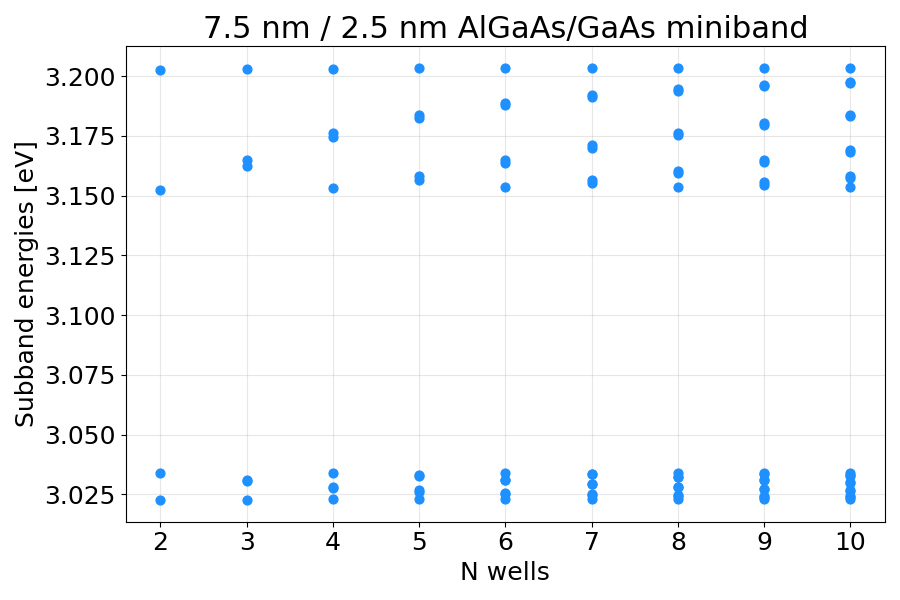

In [8]:
fontsizebase = 18
fontsizetitle = 22

fig, ax = plt.subplots(figsize=(9, 6))

for N, energies in sweep_results:
    ax.scatter([N] * len(energies), energies, color='dodgerblue', s=40, zorder=3)

ax.set_xlabel('N wells', fontsize=fontsizebase)
ax.set_ylabel('Subband energies [eV]', fontsize=fontsizebase)
ax.set_title('7.5 nm / 2.5 nm AlGaAs/GaAs miniband', fontsize=fontsizetitle)
ax.tick_params(axis='both', labelsize=fontsizebase)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()